<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Part3_Language_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Part III: Language Task
## Sentiment Analysis: True vs Fake News Classification with RNN, LSTM & Word2Vec

## Cell 1 — Install Libraries

In [1]:
!pip install numpy==1.23.5
!pip install gensim
!pip install wordcloud gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 93.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.5 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import zipfile
import io
import os

from wordcloud import WordCloud
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All imports done!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All imports done!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## Cell 3 — Upload & Load Dataset

In [3]:
from google.colab import files

uploaded = files.upload()  # Upload True vs Fake News zip

for filename in uploaded.keys():
    with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as z:
        z.extractall('/content/dataset')
    print(f"Extracted: {filename}")

# Find the CSV
for root, dirs, files_list in os.walk('/content/dataset'):
    for f in files_list:
        print(os.path.join(root, f))

Saving 10.True vs. Fake News Dataset-20260426T013449Z-3-001.zip to 10.True vs. Fake News Dataset-20260426T013449Z-3-001.zip
Extracted: 10.True vs. Fake News Dataset-20260426T013449Z-3-001.zip
/content/dataset/10.True vs. Fake News Dataset/truevsfakenews.csv
/content/dataset/10.True vs. Fake News Dataset/10.Description True Vs. Fake News Dataset.txt


## Cell 4 — Load CSV & Explore

In [4]:
df = pd.read_csv('/content/dataset/10.True vs. Fake News Dataset/truevsfakenews.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nSample rows:")
df.head(3)

Shape: (20000, 2)

Columns: ['text', 'label']

Label distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Sample rows:


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake


## Cell 5 — Task 4.5.1: Text Preprocessing

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove mentions
    text = re.sub(r'#\w+', '', text)                  # Remove hashtags
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)              # Remove special chars
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "cannot", text)
    text = re.sub(r"n\'t",   " not",    text)
    text = re.sub(r"\'re",   " are",    text)
    text = re.sub(r"\'s",    " is",     text)
    text = re.sub(r"\'d",    " would",  text)
    text = re.sub(r"\'ll",   " will",   text)
    text = re.sub(r"\'ve",   " have",   text)
    text = re.sub(r"\'m",    " am",     text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)
print("Cleaning done!")
df[['text', 'cleaned_text', 'label']].head(3)

Cleaning done!


,text,cleaned_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake


## Cell 6 — Visualise: Word Clouds & Class Distribution

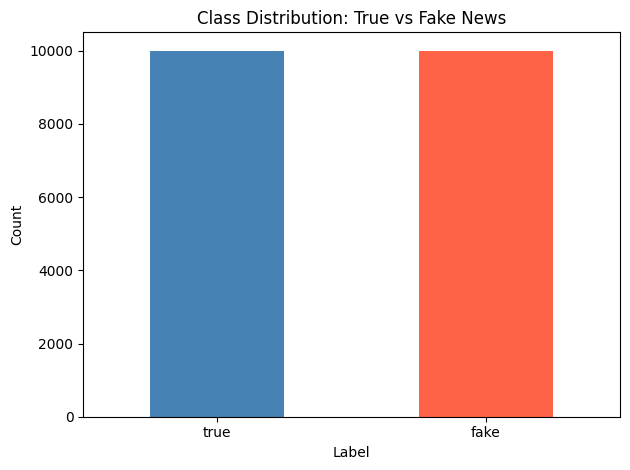

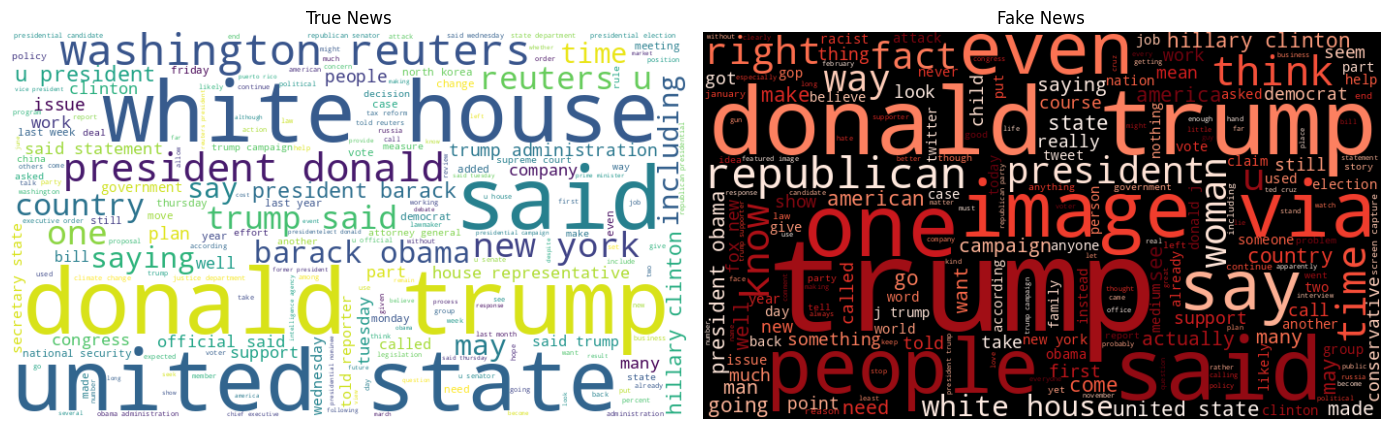

In [6]:
# Class distribution
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution: True vs Fake News')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Word Clouds
true_text = ' '.join(df[df['label'] == 'true']['cleaned_text'])
fake_text = ' '.join(df[df['label'] == 'fake']['cleaned_text'])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
wc = WordCloud(width=700, height=400, background_color='white').generate(true_text)
plt.imshow(wc, interpolation='bilinear'); plt.title('True News'); plt.axis('off')

plt.subplot(1, 2, 2)
wc = WordCloud(width=700, height=400, background_color='black', colormap='Reds').generate(fake_text)
plt.imshow(wc, interpolation='bilinear'); plt.title('Fake News'); plt.axis('off')

plt.tight_layout(); plt.show()

## Cell 7 — Tokenization & Padding

In [7]:
# Encode labels
df['label_enc'] = df['label'].map({'true': 1, 'fake': 0})

X = df['cleaned_text'].values
y = df['label_enc'].values

# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Tokenize
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocab size:   {vocab_size}")
print(f"Train shape:  {X_train_pad.shape}")
print(f"Test shape:   {X_test_pad.shape}")

Max sequence length (95th percentile): 497
Vocab size:   105246
Train shape:  (16000, 497)
Test shape:   (4000, 497)


## Cell 8 — Task 4.5.2: Model 1 — Simple RNN

In [8]:
EMBEDDING_DIM = 64

model1 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name="SimpleRNN_Model")

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Cell 9 — Train Model 1

In [9]:
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=128, validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1)],
    verbose=1
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.5145 - loss: 0.6945 - val_accuracy: 0.5138 - val_loss: 0.7002
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5266 - loss: 0.6837 - val_accuracy: 0.5350 - val_loss: 0.6777
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5427 - loss: 0.6750 - val_accuracy: 0.5263 - val_loss: 0.6836
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5221 - loss: 0.6730 - val_accuracy: 0.5106 - val_loss: 0.6798
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5302 - loss: 0.6648 - val_accuracy: 0.5288 - val_loss: 0.6807
Epoch 5: early stopping


## Cell 10 — Task 4.5.2: Model 2 — LSTM

In [10]:
model2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name="LSTM_Model")

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=128, validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1)],
    verbose=1
)

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5238 - loss: 0.6987 - val_accuracy: 0.5097 - val_loss: 0.6844
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5202 - loss: 0.6792 - val_accuracy: 0.5263 - val_loss: 0.6761
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5275 - loss: 0.6679 - val_accuracy: 0.5306 - val_loss: 0.6709
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5456 - loss: 0.6659 - val_accuracy: 0.5109 - val_loss: 0.6774
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5487 - loss: 0.6622 - val_accuracy: 0.8969 - val_loss: 0.5438
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8996 - loss: 0.2896 - val_accuracy: 0.9731 - val_loss: 0.1090
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9826 - loss: 0.0884 - val_accuracy: 0.9762 - val_loss: 0.1035
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9909 - loss: 0.0489 - val_accu

## Cell 11 — Task 4.5.2: Model 3 — LSTM with Word2Vec (GloVe)

In [11]:
import gensim.downloader as api

print("Loading GloVe embeddings... (may take a few minutes)")
embedding_model = api.load('glove-wiki-gigaword-50')
print("Loaded!")

embedding_dim    = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model3 = Sequential([
    Embedding(
        input_dim=vocab_size, output_dim=embedding_dim,
        weights=[embedding_matrix], input_length=MAX_LEN, trainable=False
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name="LSTM_Word2Vec_Model")

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=128, validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1)],
    verbose=1
)

Loading GloVe embeddings... (may take a few minutes)
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded!


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     5,262,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,262,300 (20.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,262,300 (20.07 MB)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5577 - loss: 0.6738 - val_accuracy: 0.5584 - val_loss: 0.6667
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7659 - loss: 0.5031 - val_accuracy: 0.8881 - val_loss: 0.3448
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8465 - loss: 0.3827 - val_accuracy: 0.9269 - val_loss: 0.2621
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8455 - loss: 0.3870 - val_accuracy: 0.8784 - val_loss: 0.3491
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8462 - loss: 0.3755 - val_accuracy: 0.8662 - val_loss: 0.3421
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9040 - loss: 0.3259 - val_accuracy: 0.8734 - val_loss: 0.3541
Epoch 6: early stopping


## Cell 12 — Task 4.5.3: Visualise All Models Training

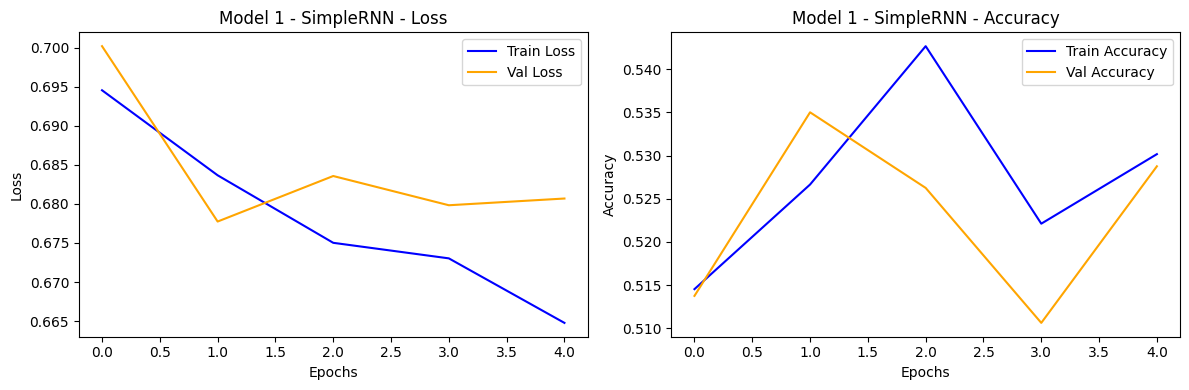

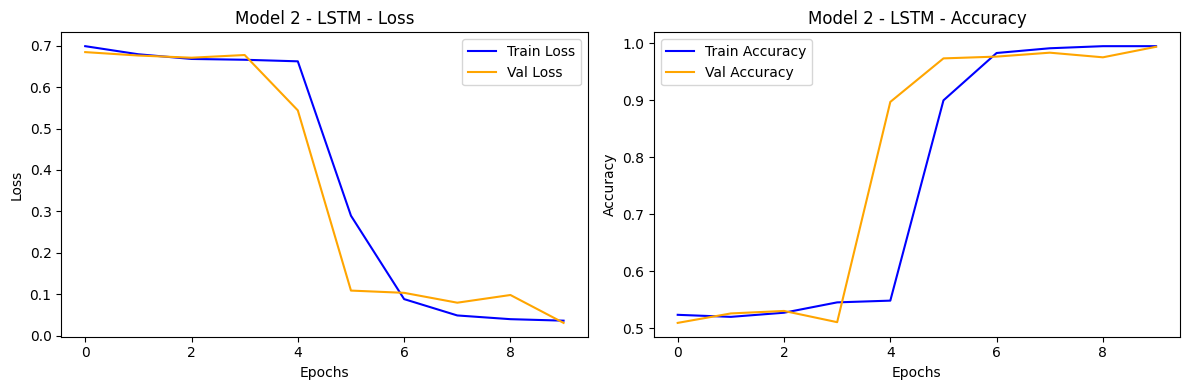

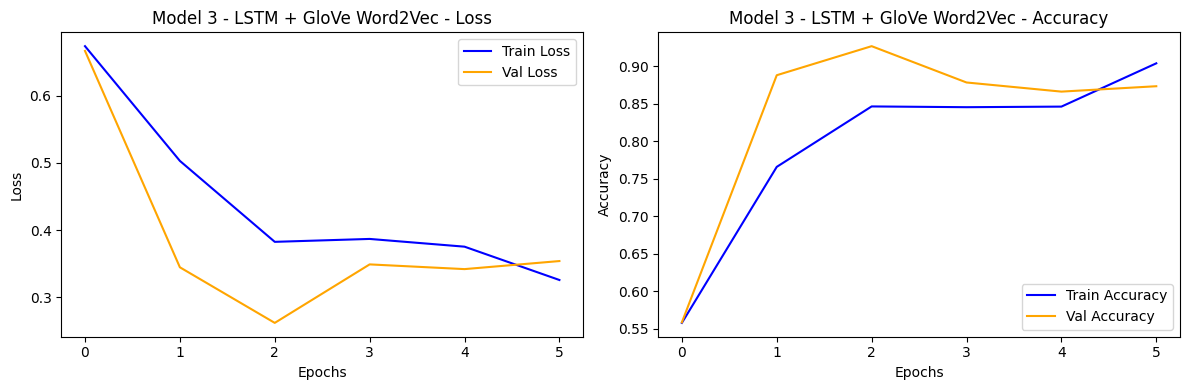

In [12]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'],     label='Train Loss',     color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss',       color='orange')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history1, 'Model 1 - SimpleRNN')
plot_history(history2, 'Model 2 - LSTM')
plot_history(history3, 'Model 3 - LSTM + GloVe Word2Vec')

## Cell 13 — Task 4.5.3: Evaluate All Models


  Model 1 - SimpleRNN
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy: 0.5497

Classification Report:
              precision    recall  f1-score   support

        Fake       0.53      0.99      0.69      2055
        True       0.86      0.09      0.16      1945

    accuracy                           0.55      4000
   macro avg       0.69      0.54      0.43      4000
weighted avg       0.69      0.55      0.43      4000



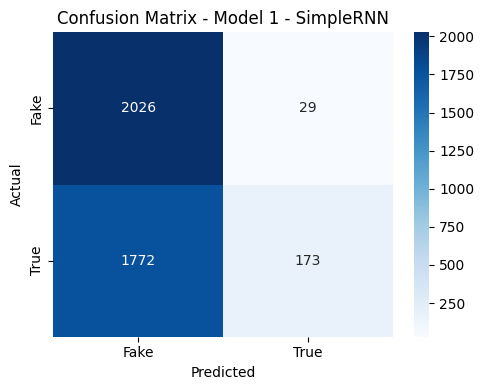


  Model 2 - LSTM
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy: 0.9925

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2055
        True       0.99      0.99      0.99      1945

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



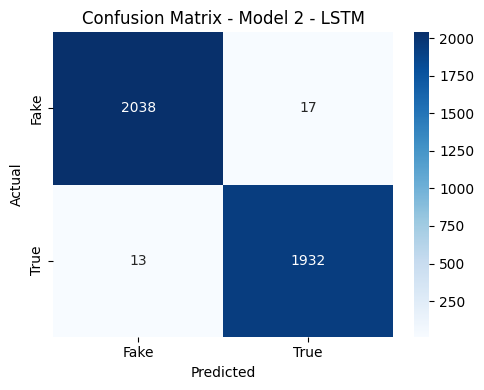


  Model 3 - LSTM + Word2Vec
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy: 0.8828

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.80      0.87      2055
        True       0.82      0.97      0.89      1945

    accuracy                           0.88      4000
   macro avg       0.89      0.89      0.88      4000
weighted avg       0.90      0.88      0.88      4000



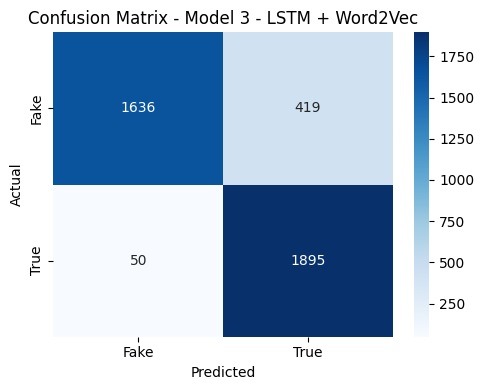

In [13]:
def evaluate_model(model, X_test, y_test, name):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int).flatten()
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    return y_pred

pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 - SimpleRNN')
pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 - LSTM')
pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 - LSTM + Word2Vec')

## Cell 14 — Task 4.5.4: Error Analysis

In [14]:
errors    = np.where(pred2 != y_test)[0]
label_map = {0: 'Fake', 1: 'True'}

print("Sample Misclassified Examples (Model 2 - LSTM):\n")
for i in errors[:3]:
    print(f"Text:            {X_test[i][:200]}...")
    print(f"True Label:      {label_map[y_test[i]]}")
    print(f"Predicted Label: {label_map[pred2[i]]}")
    print("-" * 60)

Sample Misclassified Examples (Model 2 - LSTM):

Text:            tokyo reuters every american president favorite foreign leader donald trump seems japanese prime minister shinzo abe two leader toasted bromance monday wrapped two day golf burger serious talk trade n...
True Label:      True
Predicted Label: Fake
------------------------------------------------------------
Text:            nancy pelosi obviously geographically challenged think dig hole china hear communist regime laughing president trump wrong believe laughing pelosi ridiculous statement press conference capitol hill ho...
True Label:      Fake
Predicted Label: True
------------------------------------------------------------
Text:            isle lewis scotland reuters donald trump played family root lewis island northwestern tip scotland success u republican presidential battle drawn kind rapture billionaire might like home crowd trump m...
True Label:      True
Predicted Label: Fake
----------------------------------

## Cell 15 — Model Accuracy Comparison

/tmp/ipykernel_5528/1245144130.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


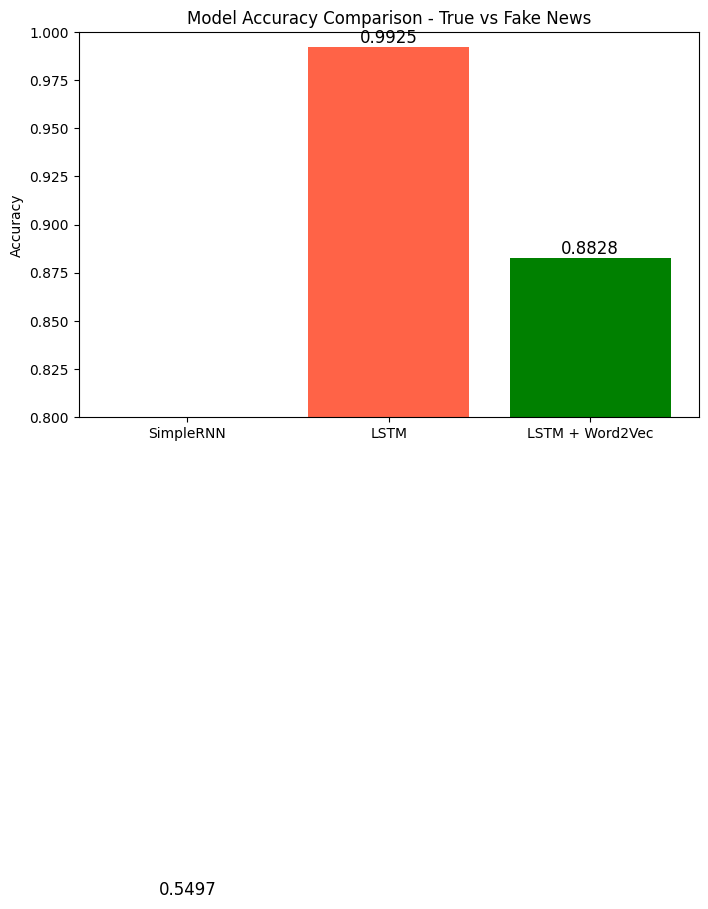

Model 1 - SimpleRNN:      0.5497
Model 2 - LSTM:           0.9925
Model 3 - LSTM+Word2Vec:  0.8828


In [15]:
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

models     = ['SimpleRNN', 'LSTM', 'LSTM + Word2Vec']
accuracies = [acc1, acc2, acc3]
colors     = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors)
plt.ylim(0.8, 1.0)
plt.title('Model Accuracy Comparison - True vs Fake News')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=12)
plt.tight_layout(); plt.show()

print(f"Model 1 - SimpleRNN:      {acc1:.4f}")
print(f"Model 2 - LSTM:           {acc2:.4f}")
print(f"Model 3 - LSTM+Word2Vec:  {acc3:.4f}")

## Cell 16 — Task 4.5.5: Gradio GUI (Extra Challenge)

In [16]:
import gradio as gr

def predict_news(text):
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = model2.predict(padded)[0][0]
    label   = "TRUE News ✅" if prob > 0.5 else "FAKE News ❌"
    return f"{label} (confidence: {prob:.2%})"

demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=5, placeholder="Paste a news article here..."),
    outputs=gr.Textbox(label="Prediction"),
    title="True vs Fake News Detector",
    description="Enter a news article and the model predicts if it is True or Fake."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eb360579706a14c65b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
